Import Required Libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Required Libraries

In [99]:
df = pd.read_csv("C:/ElevateLabs/Project-2/BR_youtube_trending_data.csv")
df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description
0,s9FH4rDMvds,LEVEI UM FORA? FINGI ESTAR APAIXONADO POR ELA!,2020-08-11T22:21:49Z,UCGfBwrCoi9ZJjKiUK8MmJNw,Pietro Guedes,22,2020-08-12T00:00:00Z,pietro|guedes|ingrid|ohara|pingrid|vlog|amigos...,263835,85095,487,4500,https://i.ytimg.com/vi/s9FH4rDMvds/default.jpg,False,False,"Salve rapaziada, neste vídeo me declarei pra e..."
1,jbGRowa5tIk,ITZY “Not Shy” M/V TEASER,2020-08-11T15:00:13Z,UCaO6TYtlC8U5ttz62hTrZgg,JYP Entertainment,10,2020-08-12T00:00:00Z,JYP Entertainment|JYP|ITZY|있지|ITZY Video|ITZY ...,6000070,714310,15176,31040,https://i.ytimg.com/vi/jbGRowa5tIk/default.jpg,False,False,ITZY Not Shy M/V[ITZY Official] https://www.yo...
2,3EfkCrXKZNs,Oh Juliana PARÓDIA - MC Niack,2020-08-10T14:59:00Z,UCoXZmVma073v5G1cW82UKkA,As Irmãs Mota,22,2020-08-12T00:00:00Z,OH JULIANA PARÓDIA|MC Niack PARÓDIA|PARÓDIAS|A...,2296748,39761,5484,0,https://i.ytimg.com/vi/3EfkCrXKZNs/default.jpg,True,False,Se inscrevam meus amores! 📬 Quer nos mandar al...
3,gBjox7vn3-g,Contos de Runeterra: Targon | A Estrada Tortuosa,2020-08-11T15:00:09Z,UC6Xqz2pm50gDCORYztqhDpg,League of Legends BR,20,2020-08-12T00:00:00Z,Riot|Riot Games|League of Legends|lol|trailer|...,300510,46222,242,2748,https://i.ytimg.com/vi/gBjox7vn3-g/default.jpg,False,False,Você se unirá aos Lunari e aos Solari em Targo...
4,npoUGx7UW7o,Entrevista com Thammy Miranda | The Noite (10/...,2020-08-11T20:04:02Z,UCEWOoncsrmirqnFqxer9lmA,The Noite com Danilo Gentili,23,2020-08-12T00:00:00Z,The Noite|The Noite com Danilo Gentili|Danilo ...,327235,22059,3972,2751,https://i.ytimg.com/vi/npoUGx7UW7o/default.jpg,False,False,Danilo Gentili recebe Thammy Miranda. Após pas...


Explore the Dataset

In [101]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66993 entries, 0 to 66992
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           66993 non-null  object
 1   title              66993 non-null  object
 2   publishedAt        66993 non-null  object
 3   channelId          66993 non-null  object
 4   channelTitle       66993 non-null  object
 5   categoryId         66993 non-null  int64 
 6   trending_date      66993 non-null  object
 7   tags               66993 non-null  object
 8   view_count         66993 non-null  int64 
 9   likes              66993 non-null  int64 
 10  dislikes           66993 non-null  int64 
 11  comment_count      66993 non-null  int64 
 12  thumbnail_link     66993 non-null  object
 13  comments_disabled  66993 non-null  bool  
 14  ratings_disabled   66993 non-null  bool  
 15  description        65515 non-null  object
dtypes: bool(2), int64(5), object(9)
memory u

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_date', 'tags', 'view_count', 'likes',
       'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
       'ratings_disabled', 'description'],
      dtype='object')

Data Cleaning and Preprocessing

In [103]:
df.drop_duplicates(inplace=True)

In [104]:
df.isnull().sum()

video_id                0
title                   0
publishedAt             0
channelId               0
channelTitle            0
categoryId              0
trending_date           0
tags                    0
view_count              0
likes                   0
dislikes                0
comment_count           0
thumbnail_link          0
comments_disabled       0
ratings_disabled        0
description          1478
dtype: int64

In [105]:
df.dropna(inplace=True)

In [106]:
df.isnull().sum()

video_id             0
title                0
publishedAt          0
channelId            0
channelTitle         0
categoryId           0
trending_date        0
tags                 0
view_count           0
likes                0
dislikes             0
comment_count        0
thumbnail_link       0
comments_disabled    0
ratings_disabled     0
description          0
dtype: int64

In [109]:
df['publishedAt'] = pd.to_datetime(df['publishedAt'])
df['trending_date'] = pd.to_datetime(df['trending_date'])

In [111]:
df['publish_year'] = df['publishedAt'].dt.year
df['publish_month'] = df['publishedAt'].dt.month
df['publish_day'] = df['publishedAt'].dt.day_name()

In [115]:
df['engagement_rate'] = (df['likes'] + df['comment_count']) / df['view_count']

In [116]:
df['like_ratio'] = df['likes'] / df['view_count']

Feature Engineering

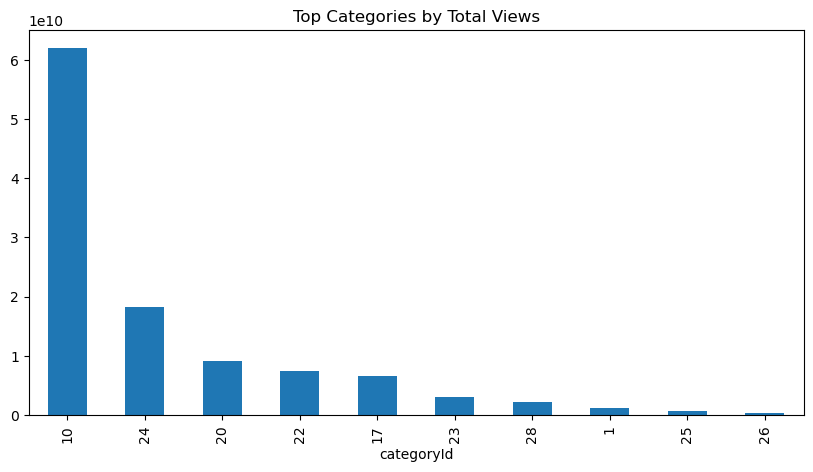

In [118]:
top_categories = df.groupby('categoryId')['view_count'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_categories.head(10).plot(kind='bar')
plt.title("Top Categories by Total Views")
plt.show()

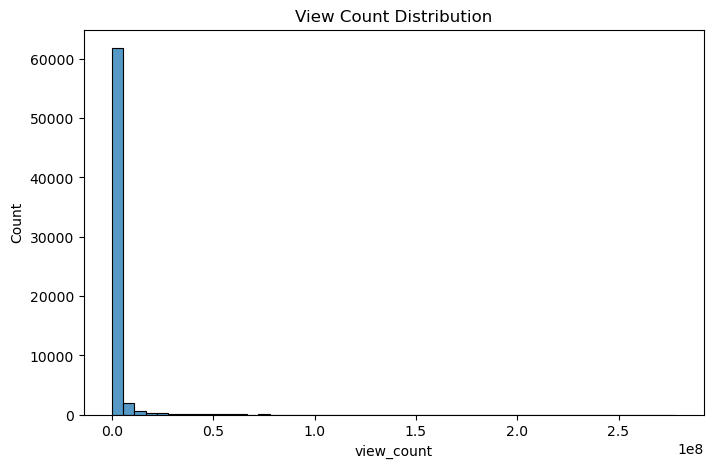

In [122]:
plt.figure(figsize=(8,5))
sns.histplot(df['view_count'], bins=50)
plt.title("View Count Distribution")
plt.show()

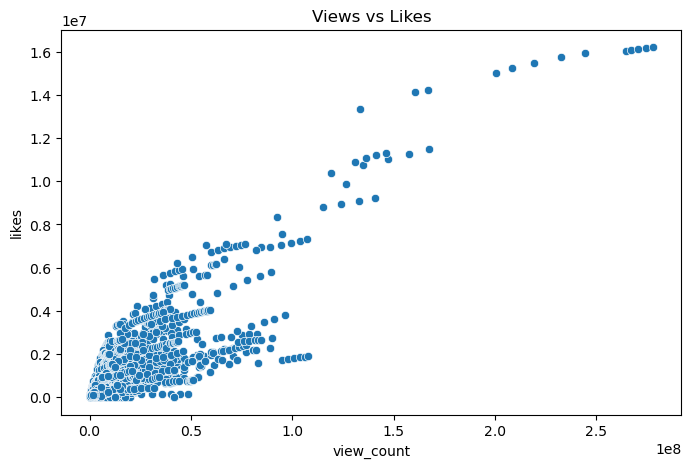

In [124]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='view_count', y='likes', data=df)
plt.title("Views vs Likes")
plt.show()

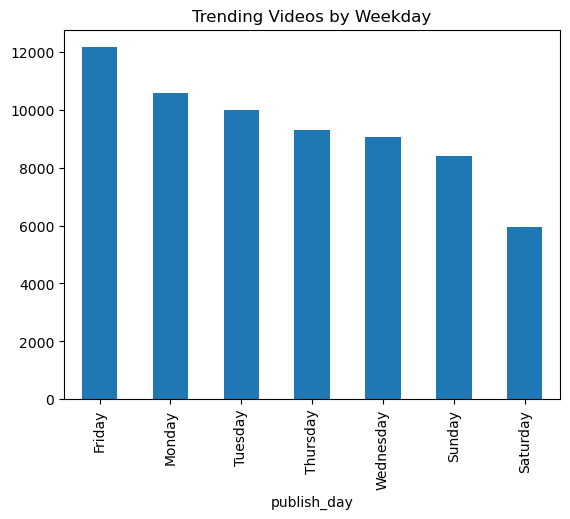

In [126]:
weekday_trend = df['publish_day'].value_counts()

weekday_trend.plot(kind='bar')
plt.title("Trending Videos by Weekday")
plt.show()

In [127]:
df['viral'] = (df['view_count'] > df['view_count'].median()).astype(int)

In [129]:
features = [
    'likes',
    'comment_count',
    'categoryId',
    'publish_month',
    'publish_day',
    'publish_year'
]

In [130]:
X = df[features]
y = df['viral']

In [134]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

Exploratory Data Analysis (EDA)

In [141]:
df['publish_day'] = df['publish_day'].map({
    'Monday':0,
    'Tuesday':1,
    'Wednesday':2,
    'Thursday':3,
    'Friday':4,
    'Saturday':5,
    'Sunday':6
})

In [143]:
df['categoryId'] = df['categoryId'].astype(int)

In [145]:
features = [
    'likes',
    'comment_count',
    'categoryId',
    'publish_month',
    'publish_day'
]

X = df[features]
y = df['viral']

In [147]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

Model Training

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Save the Cleaned Dataset

In [152]:
df.to_csv("cleaned_youtube_trending_data.csv",index=False)

Logistic Regression

In [154]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train,y_train)
log_pred = log_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Accuracy: 0.8392174843344031

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85      6497
           1       0.89      0.78      0.83      6589

    accuracy                           0.84     13086
   macro avg       0.84      0.84      0.84     13086
weighted avg       0.85      0.84      0.84     13086


Confusion Matrix:
[[5872  625]
 [1479 5110]]


Decision Tree

In [156]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.8414335931529879

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      6497
           1       0.89      0.79      0.83      6589

    accuracy                           0.84     13086
   macro avg       0.85      0.84      0.84     13086
weighted avg       0.85      0.84      0.84     13086


Confusion Matrix:
[[5829  668]
 [1407 5182]]


Random Forest

In [158]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9362677670793215

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      6497
           1       0.94      0.94      0.94      6589

    accuracy                           0.94     13086
   macro avg       0.94      0.94      0.94     13086
weighted avg       0.94      0.94      0.94     13086


Confusion Matrix:
[[6074  423]
 [ 411 6178]]


Conclusion

In [160]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.839217
1,Decision Tree,0.841434
2,Random Forest,0.936268


In [85]:
!pip install textblob

In [172]:
from textblob import TextBlob

df['sentiment'] = df['title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

df['sentiment_label'] = df['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)

df['sentiment_label'].value_counts()

sentiment_label
Neutral     56006
Positive     8020
Negative     1400
Name: count, dtype: int64

In [174]:
df['sentiment_label'] = df['sentiment'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

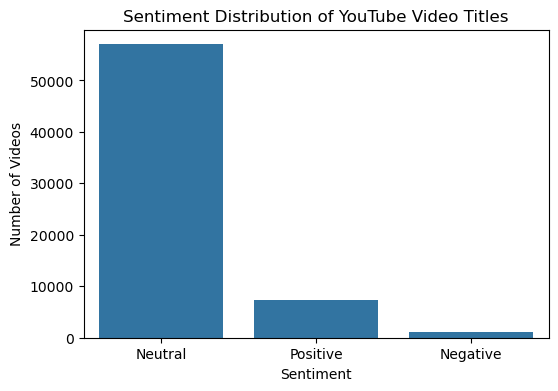

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='sentiment_label', data=df)
plt.title("Sentiment Distribution of YouTube Video Titles")
plt.xlabel("Sentiment")
plt.ylabel("Number of Videos")
plt.show()